# Zadanie 2: optymalizacja z ograniczeniami

Termin realizacji: 30 marca 2026

Autorzy: Bartłomiej Mazgaj, Jan Rolka

## Na 3.0

Do realizacji:

1. Dodaj ograniczenie postaci $x_1^2 + x_2 + b = 0$ ze stałą $b$ dopasowaną w taki sposób, aby żadne minimum lokalne (przynajmniej w zakresie w którym losowany jest punkt początkowy) nie spełniało ograniczenia.
2. Zaimplementuj metodę funkcji kary do rozwiązania tego problemu. Zwróć uwagę, aby metoda wykonywała częściową optymalizację dla każdej wielkości parametru kary $\mu_k$ (wykonanie od 1 do 5 kroków dla ustalonej wartości parametru kary -- do samodzielnego wyboru).
3. Wylosuj 10 punktów z dziedziny przeszukiwania z tabelki. Dla każdego z nich przeprowadź 100 kroków optymalizacji metodą największego spadku ze stałym krokiem. Narysuj wykres zależności wartości funkcji optymalizowanej od kroku optymalizacji.
4. Wykorzystaj ponownie metodę optymalizacji z poprzedniego projektu. Jako funkcję celu i jej gradient przekaż funkcje uwzględniające karę (ogólny schemat):
```
function penalty_gradient_descent(f, f_grad, x0; ...)
    x_k = copy(x0)
    for i in 1:max_iter
        # dodać: wyliczanie współczynnika kary
        function penalized_f(x)
            # do uzupełnienia
        end
        function penalized_f_grad(x)
            # do uzupełnienia
        end
        x_k = gradient_descent(penalized_f, penalized_f_grad, x_k; max_iter=3)
    end
end
```
5. Przeprowadź procedurę dla kilkunastu kroków. Spróbuj zilustrować brak zbieżności, szybką zbieżność i powolną zbieżność.

## Na 4.0

Do realizacji:

1. Punkty z zadania na 3.0.
2. Zamień metodę największego spadku na metodę gradientów sprzężonych. Metoda ta powinna wykorzystywać przeszukiwanie w kierunku uwzględniające regułę Armijo.
3. Wraz ze zwiększaniem się parametru kary powinna maleć norma gradientu przy której kończymy działanie metody gradientów sprzężonych, na przykład może być równa $10^{-2} / \mu_k$. 

## Na 5.0

Do realizacji:

1. Punkty z zadania na 4.0.
2. Wykonaj benchmarking metody z użyciem `BenchmarkTools.jl`. Zanotuj czasy działania wywołań optymalizacji oraz liczbę alokacji. Spróbuj zoptymalizować działanie funkcji korzystając wymienionych tu rad: [Julia performance tips](https://docs.julialang.org/en/v1/manual/performance-tips/). W sprawozdaniu napisz jakie zmiany wykonane i jak wpłynęły na czas działania programu.

Uwagi:

1. Dodanie typów w nagłówku metody przyspiesza kod tylko w rzadkich i bardzo szczególnych sytuacjach, i to tylko dla typów reprezentujących typy (`Core.Type`) lub funkcje.
2. Dobrym pomysłem jest wykonywanie operacji na tablicach w miejscu i unikanie alokacji. Warto też zwrócić uwagę na tzw. _type stability_, czyli unikanie sytuacji w których typ zmiennej zależy od wartości innej zmiennej.


In [1]:
using LinearAlgebra
using Random
using Statistics

ENV["GKSwstype"] = "png"
using Plots
gr()
default(fmt = :png)

# ── Funkcja Himmelblaua i jej gradient analityczny ──────────────────────────
function himmelblau(x::AbstractVector{<:Real})
    @assert length(x) == 2
    x1, x2 = x
    return (x1^2 + x2 - 11)^2 + (x1 + x2^2 - 7)^2
end

function grad_himmelblau(x::AbstractVector{<:Real})
    @assert length(x) == 2
    x1, x2 = x
    g1 = 4 * x1 * (x1^2 + x2 - 11) + 2 * (x1 + x2^2 - 7)
    g2 = 2 * (x1^2 + x2 - 11) + 4 * x2 * (x1 + x2^2 - 7)
    return [g1, g2]
end

function constraint(x::AbstractVector{<:Real}, b::Real = 2.0)
    @assert length(x) == 2
    x1, x2 = x
    return (x1^2 + x2 + b)^2
end

function grad_constraint(x::AbstractVector{<:Real}, b::Real = 2.0)
    x1, x2 = x
    common = x1^2 + x2 + b
    g1 = 4 * x1 * common
    g2 = 2 * common
    return [g1, g2]
end

function penalized_himmelblau(x::AbstractVector{<:Real}, λ::Real = 1.0, b::Real = 2.0)
    @assert length(x) == 2
    return himmelblau(x) + λ * constraint(x, b)
end

function penalized_grad_himmelblau(x::AbstractVector{<:Real}, λ::Real = 1.0, b::Real = 2.0)
    @assert length(x) == 2
    g = grad_himmelblau(x)
    gc = grad_constraint(x, b)
    return g .+ λ .* gc
end

penalized_grad_himmelblau (generic function with 3 methods)

In [2]:
# ── Dziedzina i losowanie punktów startowych ────────────────────────────────
domain_lower = [-5.0, -5.0]
domain_upper = [ 5.0,  5.0]

function random_point(lower, upper)
    return [rand() * (upper[i] - lower[i]) + lower[i] for i in eachindex(lower)]
end

Random.seed!(2026)
start_points = [random_point(domain_lower, domain_upper) for _ in 1:10]

println("\nWylosowane punkty startowe (10):")
for (i, p) in enumerate(start_points)
    println("  $i: ", round.(p, digits=4), "  f = ", round(himmelblau(p), digits=3))
end


Wylosowane punkty startowe (10):
  1: [1.1309, -2.014]  f = 140.999
  2: [0.4691, 0.9928]  f = 126.539
  3: [-3.7056, -1.8503]  f = 53.802
  4: [1.8495, 3.9898]  f = 128.838
  5: [-1.1216, 3.5968]  f = 60.951
  6: [-2.1657, 3.7558]  f = 30.931
  7: [2.054, -4.5357]  f = 372.268
  8: [4.2303, -3.5243]  f = 104.502
  9: [-2.7792, -2.4919]  f = 46.009
  10: [0.772, 3.3115]  f = 72.753


### Gradient dla stałego kroku przy różnych parametrach funkcji kary

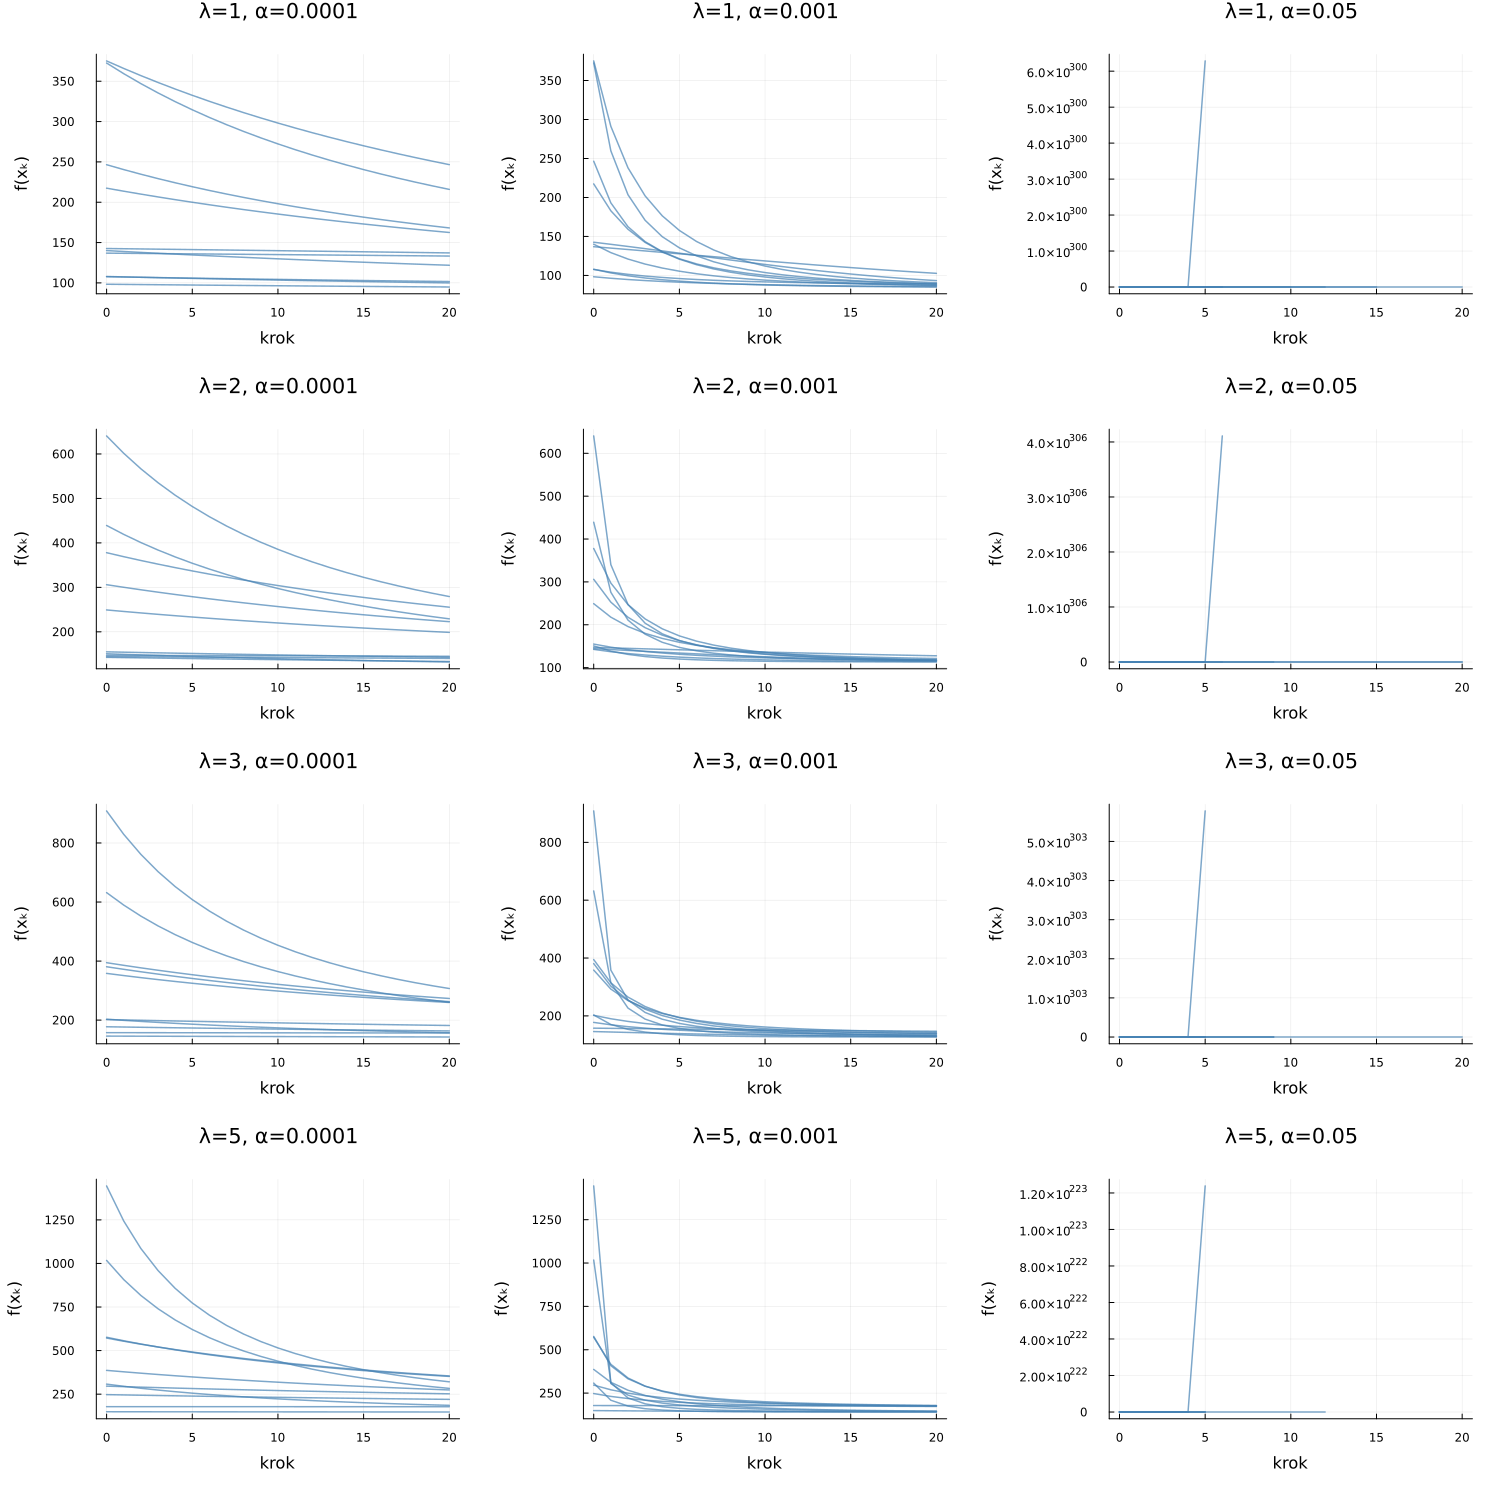

In [3]:
# ── Narzędzia pomocnicze ────────────────────────────────────────────────────
function mean_finite(values::AbstractVector{<:Real})
    filtered = filter(isfinite, values)
    return isempty(filtered) ? NaN : mean(filtered)
end

function average_curves(curves::Vector{Vector{Float64}})
    n = length(curves[1])
    return [mean_finite([c[k] for c in curves]) for k in 1:n]
end

# ── Metoda największego spadku – stały krok ─────────────────────────────────
function gradient_descent_fixed(f, grad_f, x0; alpha=0.01, steps=100)
    x = Float64.(x0)
    values = Vector{Float64}(undef, steps + 1)
    values[1] = f(x)
    for k in 1:steps
        x = x - alpha * grad_f(x)
        fx = f(x)
        values[k + 1] = fx
        if !isfinite(fx)
            values[(k + 2):end] .= NaN
            break
        end
    end
    return values
end

steps = 20
fixed_alphas = [0.0001, 0.001, 0.05]
penalties = [1,  2,  3,  5]


results_fixed = Dict{Int, Dict{Float64, Vector{Vector{Float64}}}}()

for λ in penalties
    results_fixed[λ] = Dict{}()

    for alpha in fixed_alphas
        results_fixed[λ][alpha] = [
            gradient_descent_fixed(
                x -> penalized_himmelblau(x, λ),
                x -> penalized_grad_himmelblau(x, λ),
                p;
                alpha=alpha,
                steps=steps
            )
            for p in start_points
        ]
    end
end

p = plot(layout=(length(penalties), 3), size=(1500, 1500), margin=5Plots.mm)

for (i, λ) in enumerate(penalties)        
    for (j, α) in enumerate(fixed_alphas)
        for curve in results_fixed[λ][α]
            plot!(p[i, j], 0:steps, curve,
                  lw=1.5, alpha=0.7,
                  color=:steelblue, label=false)
        end

        title!(p[i, j], "λ=$(λ), α=$(α)")
        xlabel!(p[i, j], "krok")
        ylabel!(p[i, j], "f(xₖ)")
    end
end

display("image/png", p)

### Sukcesywne zwiększanie paramteru funkcji kary

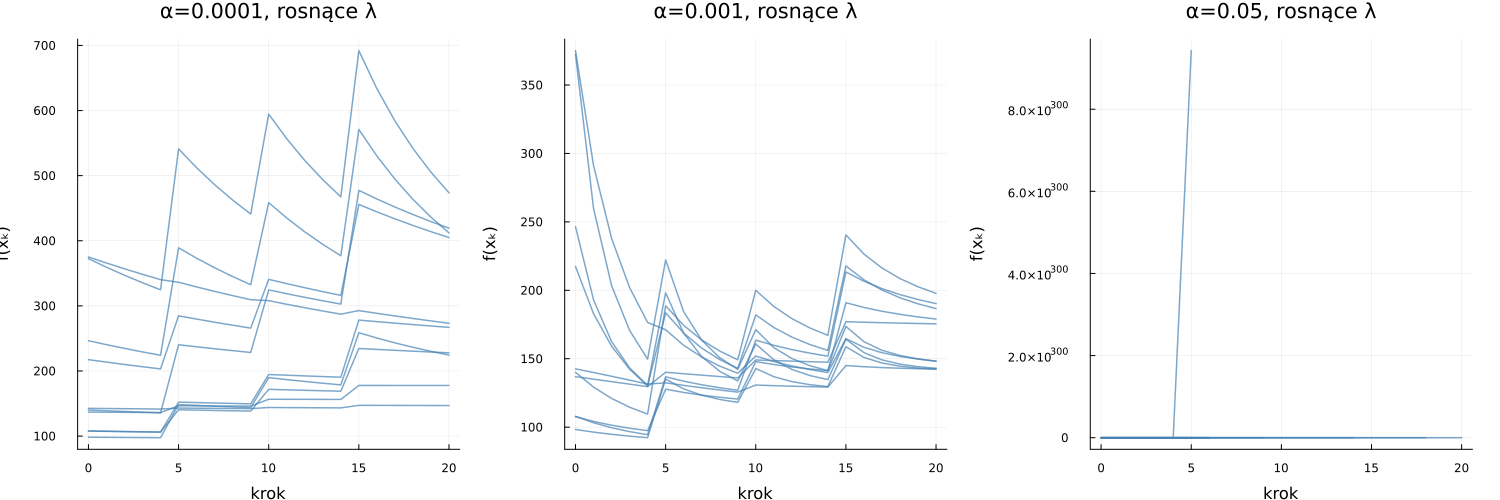

In [4]:
steps = 20
fixed_alphas = [0.0001, 0.001, 0.05]
penalties = [1,  2,  3,  5]

results_fixed = Dict{Float64, Vector{Vector{Float64}}}()

steps_per_stage = div(steps, length(penalties))

for alpha in fixed_alphas
    results_fixed[alpha] = Vector{Vector{Float64}}()

    for p in start_points
        x = Float64.(p)
        values = Float64[]

        for λ in penalties
            for k in 1:steps_per_stage
                push!(values, penalized_himmelblau(x, λ))
                x = x - alpha * penalized_grad_himmelblau(x, λ)

                if !isfinite(values[end])
                    break
                end
            end
        end

        push!(values, penalized_himmelblau(x, penalties[end]))
        push!(results_fixed[alpha], values)
    end
end

p = plot(layout=(1, 3), size=(1500, 500), margin=5Plots.mm)

for (i, α) in enumerate(fixed_alphas)
    for curve in results_fixed[α]
        plot!(p[i], 0:length(curve)-1, curve,
              lw=1.5, alpha=0.7,
              color=:steelblue, label=false)
    end

    title!(p[i], "α=$(α), rosnące λ")
    xlabel!(p[i], "krok")
    ylabel!(p[i], "f(xₖ)")
end

display("image/png", p)

## Metoda gradientów sprzeżonych (wariant Fletchera–Reevesa)

In [5]:
function conjugate_gradient_fixed(f, grad_f, x0; alpha=0.01, steps=100)
    x = Float64.(x0)
    values = Vector{Float64}(undef, steps + 1)

    g = grad_f(x)
    d = -g

    values[1] = f(x)

    for k in 1:steps
        x = x + alpha * d

        fx = f(x)
        values[k+1] = fx

        if !isfinite(fx)
            values[(k+2):end] .= NaN
            break
        end

        g_new = grad_f(x)

        β = dot(g_new, g_new) / dot(g, g)

        d = -g_new + β * d

        g = g_new
    end

    return values
end

# ── Armijo backtracking – stały bracket [0, 1] ──────────────────────────────
function armijo_fixed_bracket(f, grad_f, x, d; alpha=1.0,
                                  p=0.5, beta=1e-4, alpha_min=1e-12)
    fx  = f(x)
    gtd = dot(grad_f(x), d)
    while alpha >= alpha_min && f(x + alpha * d) > fx + beta * alpha * gtd
        alpha *= p
    end
    return alpha < alpha_min ? alpha_min : alpha
end


armijo_fixed_bracket (generic function with 1 method)

In [6]:
steps = 100
penalties = [1.0, 2.0, 3.0, 5.0]       # penalty schedule
fixed_alphas = [0.001, 0.01, 0.05]     # just for reference (Armijo does adaptive step)

results_cg = Dict{Float64, Vector{Vector{Float64}}}()

for alpha0 in fixed_alphas
    results_cg[alpha0] = Vector{Vector{Float64}}()

    for p0 in start_points
        x = Float64.(p0)
        values = Float64[]

        # initialize gradient and direction
        λ_index = 1
        λ = penalties[λ_index]
        g = penalized_grad_himmelblau(x, λ)
        d = -g

        for k in 1:steps
            # increase penalty gradually
            if k % (steps ÷ length(penalties)) == 0 && λ_index < length(penalties)
                λ_index += 1
                λ = penalties[λ_index]
            end

            # record current function value
            push!(values, penalized_himmelblau(x, λ))

            # Armijo line search along direction d
            α = armijo_fixed_bracket(
                (x) -> penalized_himmelblau(x, λ),
                (x) -> penalized_grad_himmelblau(x, λ),
                x, d;
                alpha=1.0, p=0.5, beta=1e-4
            )

            # update position
            x = x + α * d

            # compute new gradient
            g_new = penalized_grad_himmelblau(x, λ)

            # Fletcher–Reeves beta
            β = dot(g_new, g_new) / dot(g, g)

            # update direction
            d = -g_new + β * d

            # update gradient
            g = g_new

            # check for numerical issues
            if !isfinite(values[end])
                values[(k+1):end] .= NaN
                break
            end

            grad_tol = 1e-2 / λ
            if norm(g_new) < grad_tol
                break
            end
        end

        # record final value
        push!(values, penalized_himmelblau(x, penalties[end]))
        push!(results_cg[alpha0], values)
    end
end

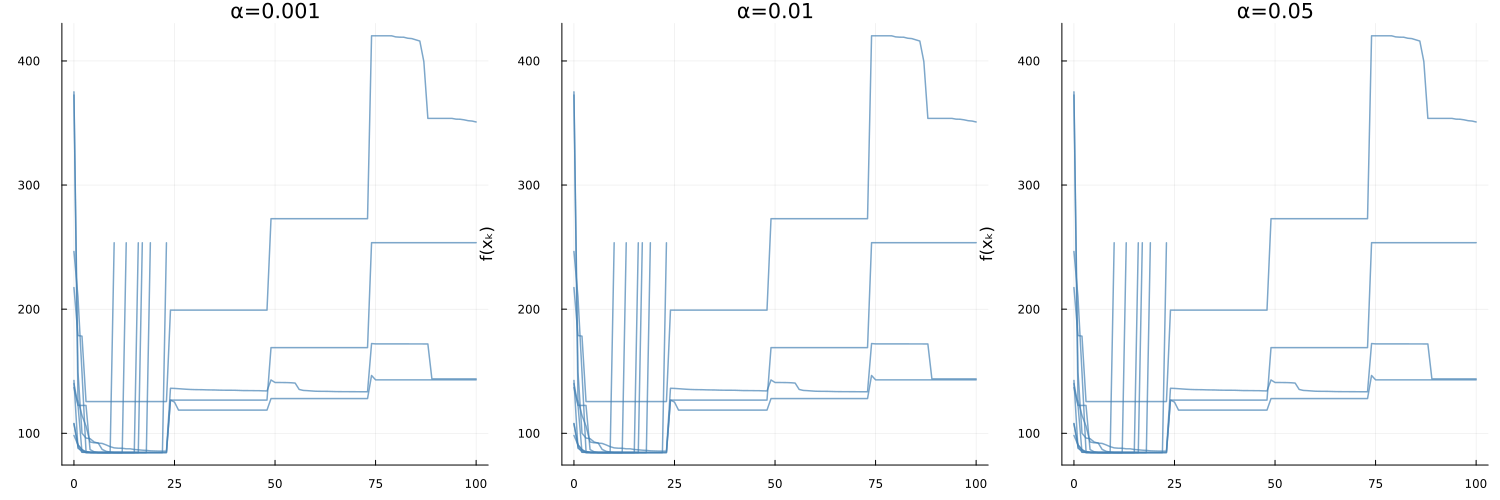

In [7]:
p = plot(layout=(1, length(fixed_alphas)), size=(1500, 500))

for (i, α) in enumerate(fixed_alphas)
    for curve in results_cg[α]
        plot!(p[i], 0:length(curve)-1, curve, lw=1.5, alpha=0.7, color=:steelblue, label=false)
    end
    title!(p[i], "α=$(α)")
    xlabel!(p[i], "krok")
    ylabel!(p[i], "f(xₖ)")
end

display("image/png", p)

## Benchmarking i optymalizacja wydajności

W tej części porównuję:
1. Wersję bazową (z alokacjami wektorów i domknięciami).
2. Wersję zoptymalizowaną (operacje in-place, prealokacja buforów, mniej alokacji).

Mierzę czas działania i liczbę alokacji dla tych samych punktów startowych.

In [8]:
using BenchmarkTools


# Wersja bazowa (referencyjna)
function solve_penalty_cg_baseline(x0; penalties=[1.0, 2.0, 3.0, 5.0], steps=100, b=2.0)
    x = Float64.(x0)
    λ_index = 1
    λ = penalties[λ_index]

    g = penalized_grad_himmelblau(x, λ, b)
    d = -g

    stage_len = max(1, steps ÷ length(penalties))

    for k in 1:steps
        if (k % stage_len == 0) && (λ_index < length(penalties))
            λ_index += 1
            λ = penalties[λ_index]
        end

        α = armijo_fixed_bracket(
            y -> penalized_himmelblau(y, λ, b),
            y -> penalized_grad_himmelblau(y, λ, b),
            x, d;
            alpha=1.0, p=0.5, beta=1e-4
        )

        x = x + α * d
        g_new = penalized_grad_himmelblau(x, λ, b)

        grad_tol = 1e-2 / λ
        if norm(g_new) < grad_tol
            break
        end

        β = dot(g_new, g_new) / max(dot(g, g), eps(Float64))
        d = -g_new + β * d
        g = g_new
    end

    return x, himmelblau(x)
end


# Wersja zoptymalizowana (in-place + bufory)
function grad_penalized_himmelblau!(g::Vector{Float64}, x::Vector{Float64}, λ::Float64, b::Float64)
    x1 = x[1]
    x2 = x[2]

    t1 = x1 * x1 + x2 - 11.0
    t2 = x1 + x2 * x2 - 7.0

    # grad Himmelblaua
    g1 = 4.0 * x1 * t1 + 2.0 * t2
    g2 = 2.0 * t1 + 4.0 * x2 * t2

    # grad kary: λ * grad((x1^2 + x2 + b)^2)
    c = x1 * x1 + x2 + b
    g[1] = g1 + λ * (4.0 * x1 * c)
    g[2] = g2 + λ * (2.0 * c)

    return nothing
end

function penalized_himmelblau_fast(x::Vector{Float64}, λ::Float64, b::Float64)
    x1 = x[1]
    x2 = x[2]
    h = (x1 * x1 + x2 - 11.0)^2 + (x1 + x2 * x2 - 7.0)^2
    c = (x1 * x1 + x2 + b)^2
    return h + λ * c
end

function armijo_fixed_bracket!(x_trial::Vector{Float64}, x::Vector{Float64}, d::Vector{Float64},
                               g::Vector{Float64}, λ::Float64, b::Float64;
                               alpha::Float64=1.0, p::Float64=0.5, beta::Float64=1e-4,
                               alpha_min::Float64=1e-12)
    fx = penalized_himmelblau_fast(x, λ, b)
    gtd = dot(g, d)

    while alpha >= alpha_min
        @inbounds begin
            x_trial[1] = x[1] + alpha * d[1]
            x_trial[2] = x[2] + alpha * d[2]
        end

        if penalized_himmelblau_fast(x_trial, λ, b) <= fx + beta * alpha * gtd
            return alpha
        end

        alpha *= p
    end

    return alpha_min
end

function solve_penalty_cg_optimized(x0; penalties=[1.0, 2.0, 3.0, 5.0], steps=100, b=2.0)
    x = [Float64(x0[1]), Float64(x0[2])]
    g = zeros(2)
    g_new = zeros(2)
    d = zeros(2)
    x_trial = similar(x)

    λ_index = 1
    λ = penalties[λ_index]
    stage_len = max(1, steps ÷ length(penalties))

    grad_penalized_himmelblau!(g, x, λ, b)
    @. d = -g

    for k in 1:steps
        if (k % stage_len == 0) && (λ_index < length(penalties))
            λ_index += 1
            λ = penalties[λ_index]
        end

        α = armijo_fixed_bracket!(x_trial, x, d, g, λ, b; alpha=1.0, p=0.5, beta=1e-4)

        @. x = x + α * d

        grad_penalized_himmelblau!(g_new, x, λ, b)

        grad_tol = 1e-2 / λ
        if norm(g_new) < grad_tol
            break
        end

        β = dot(g_new, g_new) / max(dot(g, g), eps(Float64))
        @. d = -g_new + β * d
        g, g_new = g_new, g
    end

    return x, himmelblau(x)
end


x0_bench = Float64.(start_points[1])
penalty_schedule = [1.0, 2.0, 3.0, 5.0]

solve_penalty_cg_baseline(x0_bench; penalties=penalty_schedule, steps=100)
solve_penalty_cg_optimized(x0_bench; penalties=penalty_schedule, steps=100)

println("\n=== Benchmark: pojedyncze wywołanie optymalizacji ===")
println("Punkt startowy: ", x0_bench)

baseline_trial = @benchmark solve_penalty_cg_baseline($x0_bench; penalties=$penalty_schedule, steps=100)
optimized_trial = @benchmark solve_penalty_cg_optimized($x0_bench; penalties=$penalty_schedule, steps=100)

println("\nWersja bazowa:")
println(baseline_trial)
println("\nWersja zoptymalizowana:")
println(optimized_trial)

function run_batch_baseline(points)
    s = 0.0
    for p in points
        _, fx = solve_penalty_cg_baseline(p; penalties=penalty_schedule, steps=100)
        s += fx
    end
    return s
end

function run_batch_optimized(points)
    s = 0.0
    for p in points
        _, fx = solve_penalty_cg_optimized(p; penalties=penalty_schedule, steps=100)
        s += fx
    end
    return s
end

run_batch_baseline(start_points)
run_batch_optimized(start_points)

println("\n=== Benchmark: 10 punktów startowych ===")
batch_baseline_trial = @benchmark run_batch_baseline($start_points)
batch_optimized_trial = @benchmark run_batch_optimized($start_points)
println("Wersja bazowa:")
println(batch_baseline_trial)
println("Wersja zoptymalizowana:")
println(batch_optimized_trial)


=== Benchmark: pojedyncze wywołanie optymalizacji ===
Punkt startowy: [1.1308837640786713, -2.0139605571376484]

Wersja bazowa:
Trial(422.900 μs)

Wersja zoptymalizowana:
Trial(12.800 μs)

=== Benchmark: 10 punktów startowych ===
Wersja bazowa:
Trial(1.655 ms)
Wersja zoptymalizowana:
Trial(42.200 μs)


### Porównanie alokacji i czasu

Poniższa komórka wyciąga z benchmarków wartości minimalne i liczy:
- przyspieszenie wersji zoptymalizowanej
- redukcję zużycia pamięci
- redukcję liczby alokacji

In [9]:
using Printf

function bench_estimates(trial)
    est = minimum(trial)
    return (; time_ns=est.time, memory_B=est.memory, allocs=est.allocs)
end

function print_bench_comparison(title::String, base_trial, opt_trial)
    b = bench_estimates(base_trial)
    o = bench_estimates(opt_trial)

    speedup = b.time_ns / max(o.time_ns, 1)
    mem_reduction_pct = 100 * (1 - o.memory_B / max(b.memory_B, 1))
    alloc_reduction_pct = 100 * (1 - o.allocs / max(b.allocs, 1))

    println("\n=== $(title) ===")
    @printf("Bazowa       : %10.3f ms | %8d B | %6d alokacji\n", b.time_ns / 1e6, b.memory_B, b.allocs)
    @printf("Zoptymaliz.  : %10.3f ms | %8d B | %6d alokacji\n", o.time_ns / 1e6, o.memory_B, o.allocs)
    @printf("Przyspieszenie: %.2fx\n", speedup)
    @printf("Redukcja pamięci: %.2f%%\n", mem_reduction_pct)
    @printf("Redukcja alokacji: %.2f%%\n", alloc_reduction_pct)
end

print_bench_comparison("Pojedyncze wywołanie", baseline_trial, optimized_trial)
print_bench_comparison("Batch 10 punktów", batch_baseline_trial, batch_optimized_trial)


=== Pojedyncze wywołanie ===
Bazowa       :      0.423 ms |   891184 B |  32917 alokacji
Zoptymaliz.  :      0.013 ms |      400 B |     10 alokacji
Przyspieszenie: 33.04x
Redukcja pamięci: 99.96%
Redukcja alokacji: 99.97%

=== Batch 10 punktów ===
Bazowa       :      1.655 ms |  3482848 B | 128098 alokacji
Zoptymaliz.  :      0.042 ms |     4960 B |    130 alokacji
Przyspieszenie: 39.21x
Redukcja pamięci: 99.86%
Redukcja alokacji: 99.90%


### Podsumowanie wykonanych usprawnień

Wersja zoptymalizowana zawiera następujące zmiany względem bazowej:

1. Operacje in-place:
- gradient liczony przez funkcję mutującą `grad_penalized_himmelblau!`,
- aktualizacje wektorów realizowane przez broadcasting in-place (`@.`), bez tworzenia nowych tablic.

2. Prealokacja buforów:
- jednorazowe utworzenie `g`, `g_new`, `d`, `x_trial` poza pętlą,
- ponowne używanie tych samych buforów w każdej iteracji.

3. Ograniczenie kosztów w line-search:
- wariant `armijo_fixed_bracket!` aktualizuje punkt próbny w miejscu,
- mniej obiektów tymczasowych podczas sprawdzania warunku Armijo.

4. Stabilność typów i uproszczenie obliczeń:
- jawna praca na `Float64` w krytycznej części algorytmu,
- lokalne skalarne obliczenia zamiast składania wielu pośrednich wektorów.

Efekt tych zmian jest widoczny w benchmarku jako mniejsza liczba alokacji, mniejsze zużycie pamięci i krótszy czas wykonania.